<a href="https://colab.research.google.com/github/TienPhap0102/ecommerce-abc-analysis/blob/main/ABC_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **STRATEGIC PROFICT SEGMENTATION: OPTIMAZING E-COMMERCE INVENTORY & CUSTOMER LOYALTY THROUGH ABC ANALYSIS**

**1. Context**

As the year-end peak season approaches, our E-commerce platform faces two critical resource optimization challenges:
- **Operations & Warehousing**: An expansive product catalog of **nearly 4,000 SKUs** is overwhelming inventory management and warehouse capacity.
- **Marketing & CRM**: With a **limited budget** for year-end appreciation gifts, the company must **identify and prioritize high-value customers** to maximize Return on Investment (ROI) and foster loyalty.

This project applies the **Pareto Principle** (80/20 Rule) and **ABC Analysis** to strategically segment two core entities—Products and Customers—based on their contribution to total Profit.

**2. Project Objectives**

The analysis is divided into two primary workstreams:

- **Workstream 1**: Inventory Strategy Optimization (Product Focus)
  - Classify 4,000 SKUs into three strategic tiers (A, B, and C) based on cumulative profit contribution.
  - **Goal**: Identify the "Critical Few" products (Group A) that drive the majority of the bottom line.
  - **Outcome:** Provide actionable recommendations for inventory turnover frequency, warehouse space allocation, and supply chain priority to minimize costs while securing high-profit margins.

- **Workstream 2**: Strategic Customer Loyalty Program (Customer Focus)
  - Segment the customer base into A, B, and C groups according to their lifetime value (Total Profit).
  - **Goal**: Validate if the customer distribution follows the Pareto law and determine the feasibility of a VIP gift strategy (allocating 80% of the budget to Group A).
  - **Outcome**: Generate a targeted list for the 500 premium gift slots and define the persona (Income & Occupation) of "Group A" customers to guide future acquisition campaigns.

  

# **1. Set up & Library**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# **2. Data Loading**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**`EcomSale table`**: Store sales information

In [ ]:
sales = pd.read_csv('/content/drive/MyDrive/1. DATA ANH TÚ/Buổi 4 - ABC analyst /DATA/EcomSales.csv')
sales.head(2)

,RowID,OrderID,OrderDate,CustomerID,Segment,RegionCode,ProductCode,Quantity,Sales,Discount,Profit
0,25221,IN-2012-TH211151-41003,4/4/2020,TH-211151,Corporate,RRR0001,P000001,13,416,0.0,208.0
1,29464,ID-2013-BD116051-41518,9/1/2021,BD-116051,Consumer,R0002,PPP000002,4,20,0.0,10.0


**`Product table`**: Store products information

In [ ]:
products = pd.read_csv('/content/drive/MyDrive/1. DATA ANH TÚ/Buổi 4 - ABC analyst /DATA/Product.csv')
products.head(2)

,ProductCode,Product,Category,Subcategory
0,P000001,Soap & Glory Endless Glove Moisturizing Hand C...,Body care,"bath oils, bubbles and soaks"
1,P000002,Pantene Pro-V Truly Relaxed Hair Lightweight C...,Body care,"bath oils, bubbles and soaks"


**`Customer table`**: Store customers information

In [ ]:
customers = pd.read_csv('/content/drive/MyDrive/1. DATA ANH TÚ/Buổi 4 - ABC analyst /DATA/Customer.csv')
customers.head(2)

,CustomerID,FirstName,LastName,BirthDate,MaritalStatus,Gender,EmailAddress,AnnualIncome,EducationLevel,Occupation,HomeOwner
0,TH-211151,Jon,Huang,6/18/1962,M,M,jon24@hotmail.com,90000,Bachelors,Professional,Y
1,BD-116051,Eugene,Torres,6/16/1985,S,M,eugene10@hotmail.com,60000,Bachelors,Professional,N


**`Region table`**: Store regional information

In [ ]:
region = pd.read_csv('/content/drive/MyDrive/1. DATA ANH TÚ/Buổi 4 - ABC analyst /DATA/Region.csv')
region.head(2)

,RegionCode,City,State,Country,Countrylatitude,Countrylongitude,Region,Market
0,R0001,Jalalabad,Nangarhar,Afghanistan,33.93911,67.709953,Southern Asia,Asia Pacific
1,R0002,Herat,Hirat,Afghanistan,33.93911,67.709953,Southern Asia,Asia Pacific


# **3. Data Preprocessing & Cleaning**

## **3.1. `Sales table`**

In [ ]:
# Data overview
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   RowID        51290 non-null  int64  
 1   OrderID      51290 non-null  object 
 2   OrderDate    51290 non-null  object 
 3   CustomerID   51290 non-null  object 
 4   Segment      51290 non-null  object 
 5   RegionCode   51290 non-null  object 
 6   ProductCode  51290 non-null  object 
 7   Quantity     51290 non-null  int64  
 8   Sales        51290 non-null  int64  
 9   Discount     51290 non-null  float64
 10  Profit       51290 non-null  float64
dtypes: float64(2), int64(3), object(6)
memory usage: 4.3+ MB


In [ ]:
# Check duplicate
sales.duplicated().sum()

np.int64(0)

In [ ]:
# Column stats
sales.describe().T

,count,mean,std,min,25%,50%,75%,max
RowID,51290.0,25645.500000,14806.291990,1.0,12823.25,25645.5,38467.75,51290.00
Quantity,51290.0,5.415832,4.908234,1.0,2.00,4.0,7.00,20.00
Sales,51290.0,127.074946,236.074764,2.0,25.00,56.0,132.00,3940.00
Discount,51290.0,0.142908,0.212280,0.0,0.00,0.0,0.20,0.85
Profit,51290.0,20.772346,83.582680,-1746.0,0.00,7.2,25.00,1820.00


**Observation:**
- 51290 data rows + 11 columns
- No null values
- No duplicate values
- Matching data types
- There appear to be **outliers** in the record lines related to **Profit, Sales, Quantity, and Discount**.

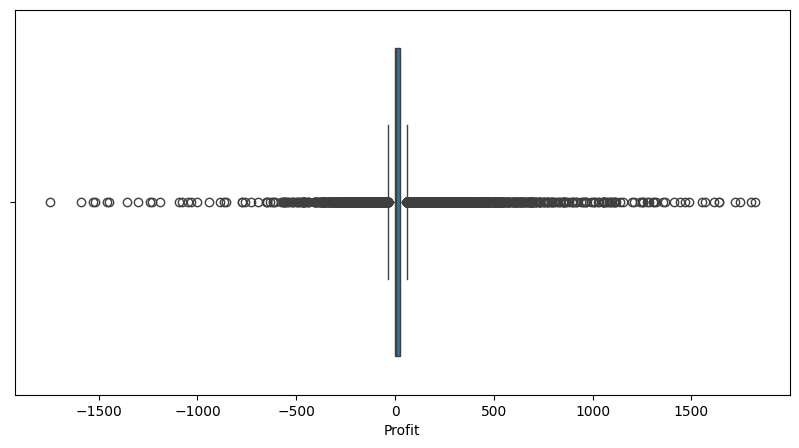

In [ ]:
# box plot check outlier của profit
plt.figure(figsize=(10, 5))
sns.boxplot(x=sales['Profit'])
plt.show()


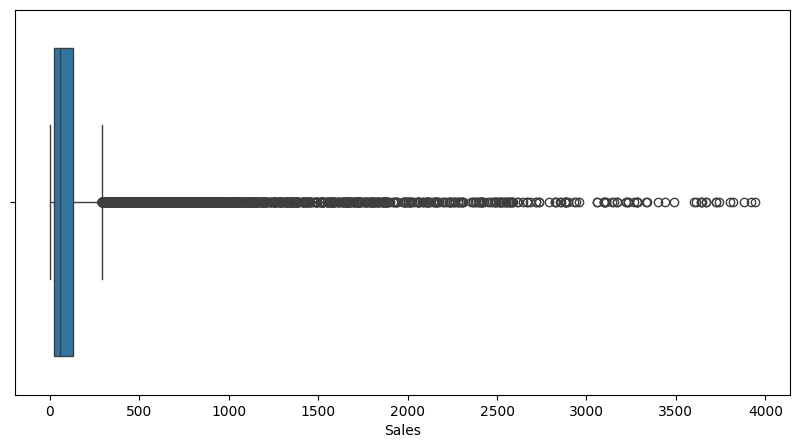

In [ ]:
# check outlier của sales
plt.figure(figsize=(10, 5))
sns.boxplot(x=sales['Sales'])
plt.show()

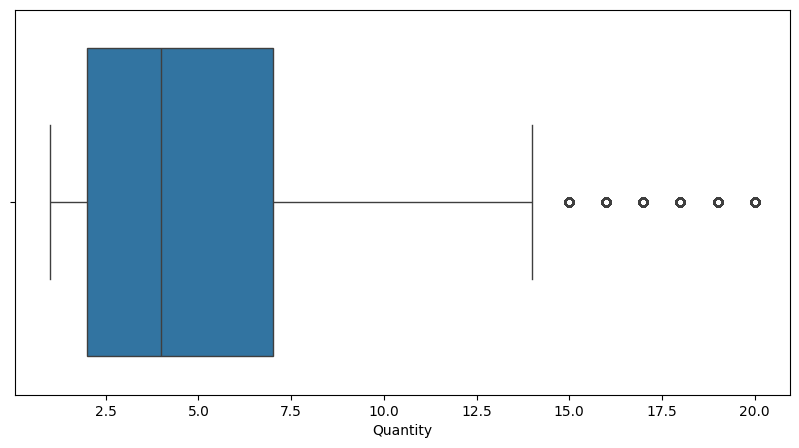

In [ ]:
# Check outlier của quantity
plt.figure(figsize=(10, 5))
sns.boxplot(x=sales['Quantity'])
plt.show()

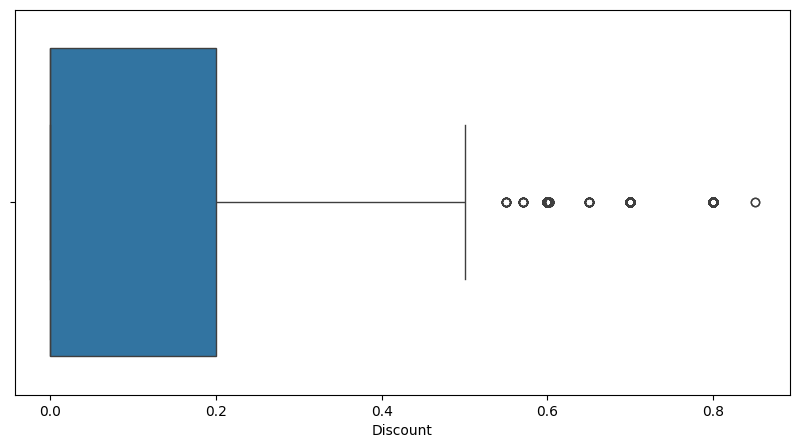

In [ ]:
# Check outlier của Discount
plt.figure(figsize=(10, 5))
sns.boxplot(x=sales['Discount'])
plt.show()

**Observation:**

- **Profit:** Outliers exist in both positive and negative territories --> Segmented into **Profitable** (for ABC analysis) and **Loss-making groups** to prevent data skewness.

- **Sales & Quantity:** All outliers are strictly positive --> Retained as they represent "**High-Value Bulk Orders**" and **reflect true market demand**.

- **Discount Logic:** Outliers are strictly within the 0% to 100% range.

In [ ]:
# Segmenting Profit_group
sales['Profit_Group'] = sales['Profit'].apply(lambda x: 'Profitable' if x > 0 else 'Loss')
sales.head()

,RowID,OrderID,OrderDate,CustomerID,Segment,RegionCode,ProductCode,Quantity,Sales,Discount,Profit,Outlier_check,Profit_Group
0,25221,IN-2012-TH211151-41003,4/4/2020,TH-211151,Corporate,RRR0001,P000001,13,416,0.0,208.0,Outlier,Profitable
1,29464,ID-2013-BD116051-41518,9/1/2021,BD-116051,Consumer,R0002,PPP000002,4,20,0.0,10.0,Normal,Profitable
2,27311,IN-2015-TS212051-42173,6/18/2023,TS-212051,Corporate,R0003,P000003,2,20,0.0,8.0,Normal,Profitable
3,28882,IN-2014-SU206651-41899,9/17/2022,SU-206651,Self-Employed,R0003,P000004,4,556,0.0,55.6,Normal,Profitable
4,27992,IN-2015-GM144551-42217,8/1/2023,GM-144551,Self-Employed,R0003,P000005,2,6,0.0,0.6,Normal,Profitable


In [ ]:
sales_agg1 = sales.groupby('Profit_Group', as_index = False).agg(Total_Profit = ('Profit', 'sum'),
                                                                 Total_Order = ('OrderID', 'nunique'),
                                                                 )
sales_agg1['AOV'] = sales_agg1['Total_Profit'] / sales_agg1['Total_Order']
sales_agg1

,Profit_Group,Total_Profit,Total_Order,AOV
0,Loss,-346988.228,7962,-43.580536
1,Profitable,1412401.878,20554,68.716643


## **3.2. `Product table`**

In [ ]:
# Data overview
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28356 entries, 0 to 28355
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ProductCode  28356 non-null  object
 1   Product      28356 non-null  object
 2   Category     28356 non-null  object
 3   Subcategory  28356 non-null  object
dtypes: object(4)
memory usage: 886.3+ KB


In [ ]:
# Check duplicate
products.duplicated().sum()

np.int64(0)

**Observation:**
- 28356 data rows + 4 columns
- No null values
- No duplicate values
- Matching data types

## **3.3. `Customer table`**

In [ ]:
# Data overview
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17415 entries, 0 to 17414
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   CustomerID      17415 non-null  object
 1   FirstName       17415 non-null  object
 2   LastName        17415 non-null  object
 3   BirthDate       17415 non-null  object
 4   MaritalStatus   17415 non-null  object
 5   Gender          17291 non-null  object
 6   EmailAddress    17415 non-null  object
 7   AnnualIncome    17415 non-null  int64 
 8   EducationLevel  17415 non-null  object
 9   Occupation      17415 non-null  object
 10  HomeOwner       17415 non-null  object
dtypes: int64(1), object(10)
memory usage: 1.5+ MB


In [ ]:
# Check duplicate
customers.duplicated().sum()

np.int64(0)

**Observation:**
- 17291 data rows + 11 columns
- No null values
- No duplicate values
- Matching data types

## **3.4. `Region table`**

In [ ]:
# Data overview
region.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3828 entries, 0 to 3827
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   RegionCode        3828 non-null   object 
 1   City              3828 non-null   object 
 2   State             3828 non-null   object 
 3   Country           3828 non-null   object 
 4   Countrylatitude   3828 non-null   float64
 5   Countrylongitude  3828 non-null   float64
 6   Region            3828 non-null   object 
 7   Market            3828 non-null   object 
dtypes: float64(2), object(6)
memory usage: 239.4+ KB


In [ ]:
# Check duplicate
region.duplicated().sum()

np.int64(0)

**Observation:**
- 3828 data rows + 8 columns
- No null values
- No duplicate values
- Matching data types

# **4. Exloratery Data Analysis & Visualization**

## **4.1. Time series trend**

/tmp/ipykernel_619/3027786067.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_trend = sales.resample('M', on='OrderDate')[['Sales', 'Profit']].sum()


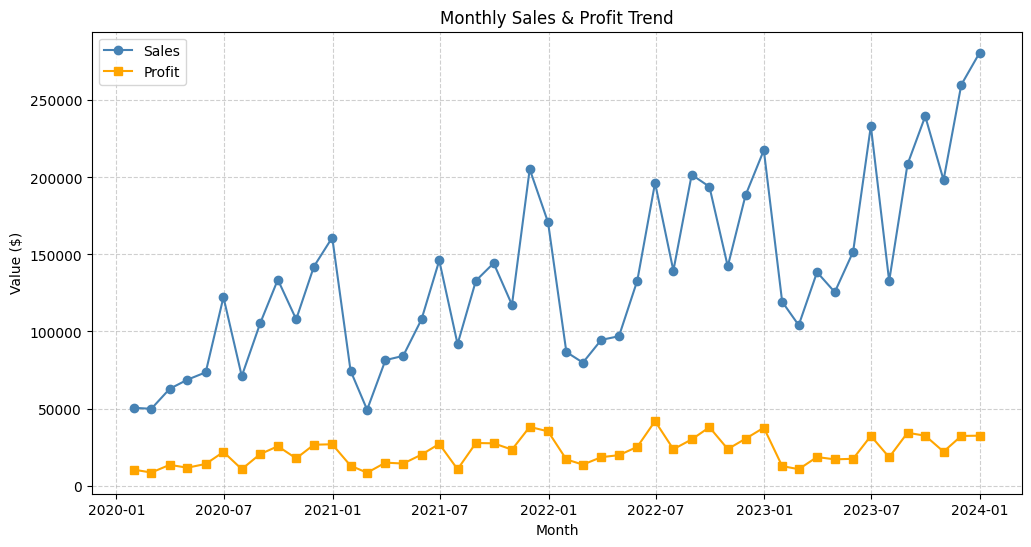

In [ ]:
# Convert data type
sales['OrderDate'] = sales['OrderDate'].astype('datetime64[ns]')
monthly_trend = sales.resample('M', on='OrderDate')[['Sales', 'Profit']].sum()

# Line chart
plt.figure(figsize=(12, 6))
plt.plot(monthly_trend.index, monthly_trend['Sales'], marker='o', label='Sales', color='steelblue')
plt.plot(monthly_trend.index, monthly_trend['Profit'], marker='s', label='Profit', color='orange')
plt.title('Monthly Sales & Profit Trend')
plt.xlabel('Month')
plt.ylabel('Value ($)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

**Observation:**
Business activity experiences strong seasonal **growth in Q3 and Q**4 and **significant declines in Q1 and Q2**, which can put **pressure on warehouse capacity**. However, profit growth is not always linearly proportional to revenue, indicating volatile profit margins.

**4.2. Category Mix**

In [ ]:
df_sales = pd.merge(sales, products, on='ProductCode', how='left')
df_sales['Subcategory'] = df_sales['Subcategory'].fillna('Other')

category_profit = df_sales.groupby('Category')['Sales'].sum().reset_index()

fig = px.pie(category_profit, values='Sales', names='Category',
             title='Sales Distribution by Product Category',
             hole=0.3)
fig.update_traces(textposition='inside', textinfo='percent+label')
fig.show()

**Observation:**
**Body care** accounts for the majority of order volume (>51%). The category with the **lowest revenue** contribution is **Face Care**, at approximately 5.59%. The remaining categories contribute relatively evenly, **at around 13-15%**.

## **4.3. Distribution of Profit**


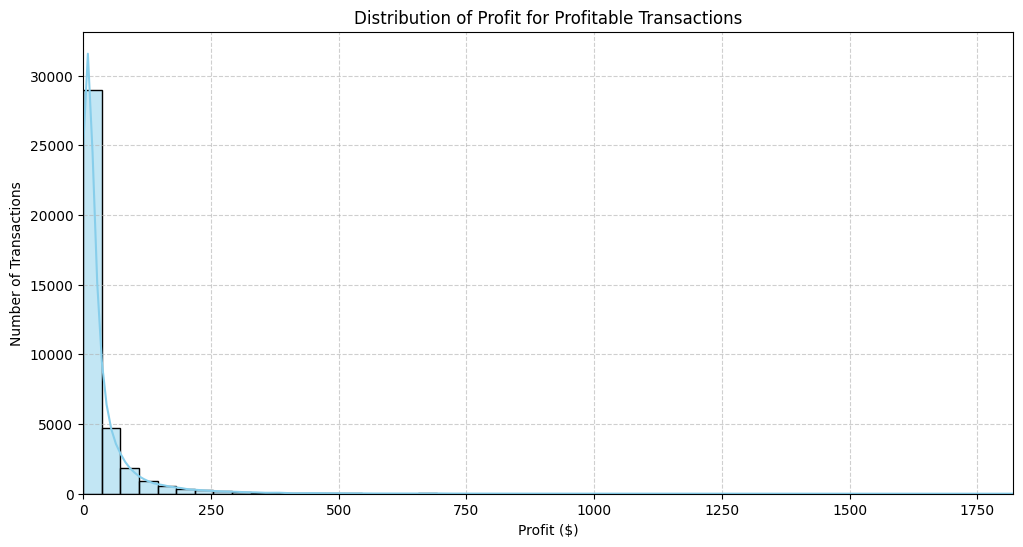

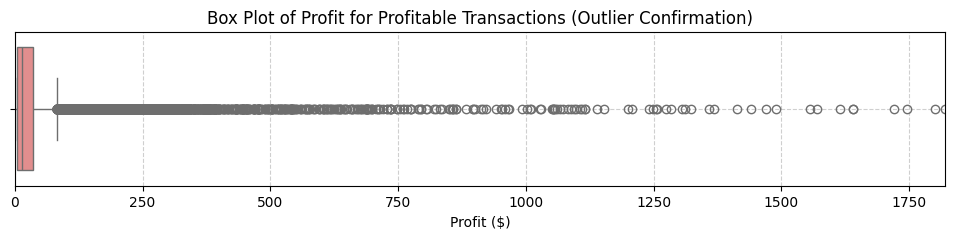

In [ ]:
# Filter for profitable transactions
profitable_sales = sales[sales['Profit_Group'] == 'Profitable']

# Plotting the histogram of Profit for profitable transactions
plt.figure(figsize=(12, 6))
sns.histplot(profitable_sales['Profit'], bins=50, kde=True, color='skyblue')
plt.title('Distribution of Profit for Profitable Transactions')
plt.xlabel('Profit ($)')
plt.ylabel('Number of Transactions')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlim(0, profitable_sales['Profit'].max())
plt.show()

# Additionally, show a box plot focusing on the profitable segment to clearly show outliers
plt.figure(figsize=(12, 2))
sns.boxplot(x=profitable_sales['Profit'], color='lightcoral')
plt.title('Box Plot of Profit for Profitable Transactions (Outlier Confirmation)')
plt.xlabel('Profit ($)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlim(0, profitable_sales['Profit'].max())
plt.show()


**Key Insight:** As observed from the histogram and box plot, the distribution of profit for profitable transactions is heavily skewed, with a significant portion of the total profit concentrated in a smaller number of high-profit transactions (positive outliers). This confirms that a 'critical few' products and customers likely drive the majority of the profit, underscoring the necessity and effectiveness of applying ABC Analysis for strategic segmentation.

## **4.3. Segment Comparison (Sales & Profit by Customer Segment)**


/tmp/ipykernel_619/2953732146.py:6: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




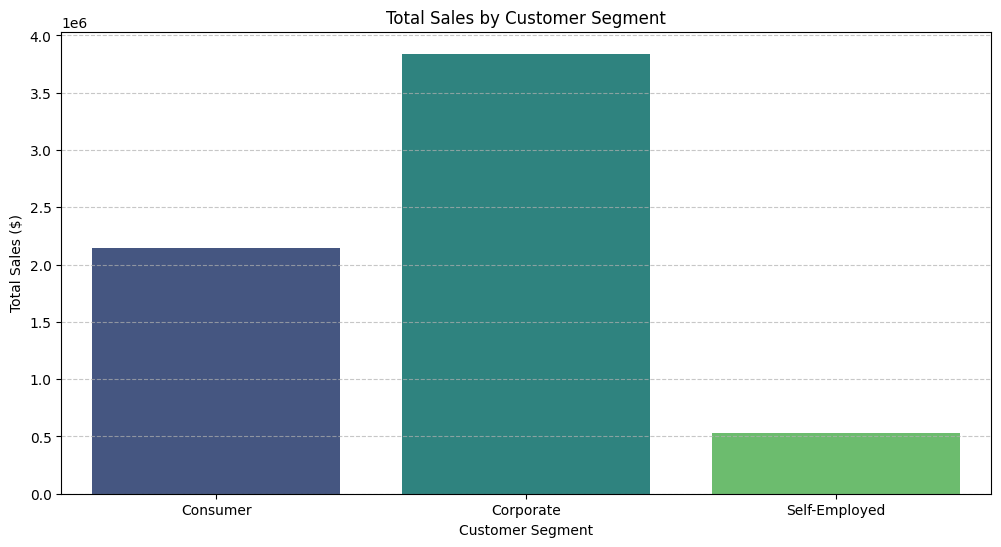

/tmp/ipykernel_619/2953732146.py:15: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




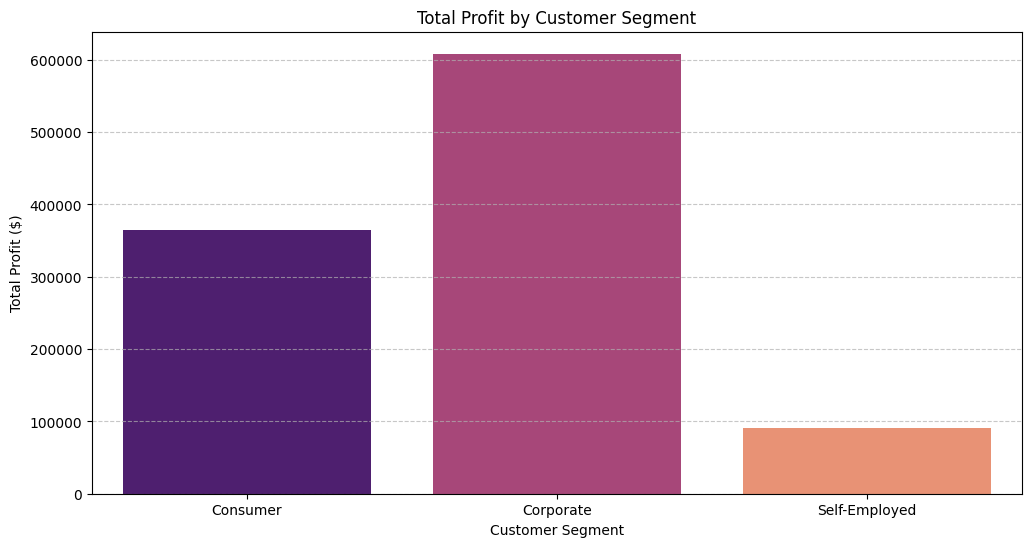

In [ ]:
# Group sales and profit by Segment
segment_performance = sales.groupby('Segment')[['Sales', 'Profit']].sum().reset_index()

# Create a bar plot for Sales by Segment
plt.figure(figsize=(12, 6))
sns.barplot(x='Segment', y='Sales', data=segment_performance, palette='viridis')
plt.title('Total Sales by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Total Sales ($)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Create a bar plot for Profit by Segment
plt.figure(figsize=(12, 6))
sns.barplot(x='Segment', y='Profit', data=segment_performance, palette='magma')
plt.title('Total Profit by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Total Profit ($)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


**Key Insight:** As observed from the bar charts, **Consumer** customers contribute the largest share to total sales. However, their profit margin might be lower compared to the **Corporate** segment, which often suggests higher volume but potentially lower individual transaction profitability. This highlights the need for targeted strategies for each segment, balancing volume and profitability.

# **5. ABC Analysis**

## **5.1. Workstream 1: Inventory Strategy Optimization**

In [ ]:
# Merge data sales & products
df_sales = pd.merge(sales, products, on='ProductCode', how='left')
df_sales.head(2)
# Handling Product Code Nan
df_sales[['Subcategory','Product', 'Category']] = df_sales[['Subcategory','Product', 'Category']].fillna('Other')
df_sales.head(2)

# Filter df_sales for profitable transactions
profitable_df_sales = df_sales[df_sales['Profit'] > 0]
profitable_df_sales.head(2)

,RowID,OrderID,OrderDate,CustomerID,Segment,RegionCode,ProductCode,Quantity,Sales,Discount,Profit,Outlier_check,Profit_Group,Product,Category,Subcategory
0,25221,IN-2012-TH211151-41003,2020-04-04,TH-211151,Corporate,RRR0001,P000001,13,416,0.0,208.0,Outlier,Profitable,Soap & Glory Endless Glove Moisturizing Hand C...,Body care,"bath oils, bubbles and soaks"
1,29464,ID-2013-BD116051-41518,2021-09-01,BD-116051,Consumer,R0002,PPP000002,4,20,0.0,10.0,Normal,Profitable,Other,Other,Other


In [ ]:
# Calculate grouppby ProductCode
product_profit = profitable_df_sales.groupby('ProductCode', as_index= False).agg(Total_Profit = ('Profit', 'sum')).sort_values(by='Total_Profit', ascending=False)
sum_profit = product_profit['Total_Profit'].sum()
product_profit['Percentage'] = product_profit['Total_Profit'] / sum_profit
product_profit['Cumulative_Percentage'] = product_profit['Percentage'].cumsum()
product_profit.head(20)


,ProductCode,Total_Profit,Percentage,Cumulative_Percentage
114,P000116,13218.832,0.009359,0.009359
287,P000303,8797.966,0.006229,0.015588
113,P000115,7699.594,0.005451,0.021040
723,P000866,6984.000,0.004945,0.025984
394,P000429,6444.340,0.004563,0.030547
1496,P002215,6411.380,0.004539,0.035086
991,P001270,6142.076,0.004349,0.039435
1260,P001735,5426.550,0.003842,0.043277
1527,P002295,5411.120,0.003831,0.047108
323,P000345,5390.100,0.003816,0.050925


In [ ]:
# determine cutting point
product_profit.loc[product_profit['Cumulative_Percentage'] <= 0.8, 'Group'] = 'A'
product_profit.loc[(product_profit['Cumulative_Percentage'] > 0.8) & (product_profit['Cumulative_Percentage'] <= 0.95), 'Group'] = 'B'
product_profit.loc[product_profit['Cumulative_Percentage'] > 0.95, 'Group'] = 'C'
product_profit.head(20)
#

,ProductCode,Total_Profit,Percentage,Cumulative_Percentage,Group
114,P000116,13218.832,0.009359,0.009359,A
287,P000303,8797.966,0.006229,0.015588,A
113,P000115,7699.594,0.005451,0.021040,A
723,P000866,6984.000,0.004945,0.025984,A
394,P000429,6444.340,0.004563,0.030547,A
1496,P002215,6411.380,0.004539,0.035086,A
991,P001270,6142.076,0.004349,0.039435,A
1260,P001735,5426.550,0.003842,0.043277,A
1527,P002295,5411.120,0.003831,0.047108,A
323,P000345,5390.100,0.003816,0.050925,A


In [ ]:
# ABC analysis summary
summary_abc = product_profit.groupby('Group', as_index = False).agg(sum_profit = ('Total_Profit', 'sum'),
                                                                    Total_product = ('ProductCode','count'))
summary_abc['Profit_pct'] = summary_abc['sum_profit'] / summary_abc['sum_profit'].sum()
summary_abc['Product_pct'] = summary_abc['Total_product'] / summary_abc['Total_product'].sum()
summary_abc.head()

,Group,sum_profit,Total_product,Profit_pct,Product_pct
0,A,1129919.068,1232,0.799998,0.348121
1,B,211781.350,1019,0.149944,0.287934
2,C,70701.460,1288,0.050058,0.363945


In [ ]:
fig = px.pie(summary_abc, values='Product_pct', names='Group',
             title='Product Distribution by ABC Group',
             hole=0.3)
fig.update_traces(textposition='inside', textinfo='percent+label')
fig.show()

In [ ]:
product_profit['cum_pct'] = product_profit['Cumulative_Percentage'] * 100
product_profit = product_profit.reset_index(drop = True)
product_profit.head()

,ProductCode,Total_Profit,Percentage,Cumulative_Percentage,Group,cum_pct
0,P000116,13218.832,0.009359,0.009359,A,0.935912
1,P000303,8797.966,0.006229,0.015588,A,1.558820
2,P000115,7699.594,0.005451,0.021040,A,2.103962
3,P000866,6984.000,0.004945,0.025984,A,2.598438
4,P000429,6444.340,0.004563,0.030547,A,3.054707


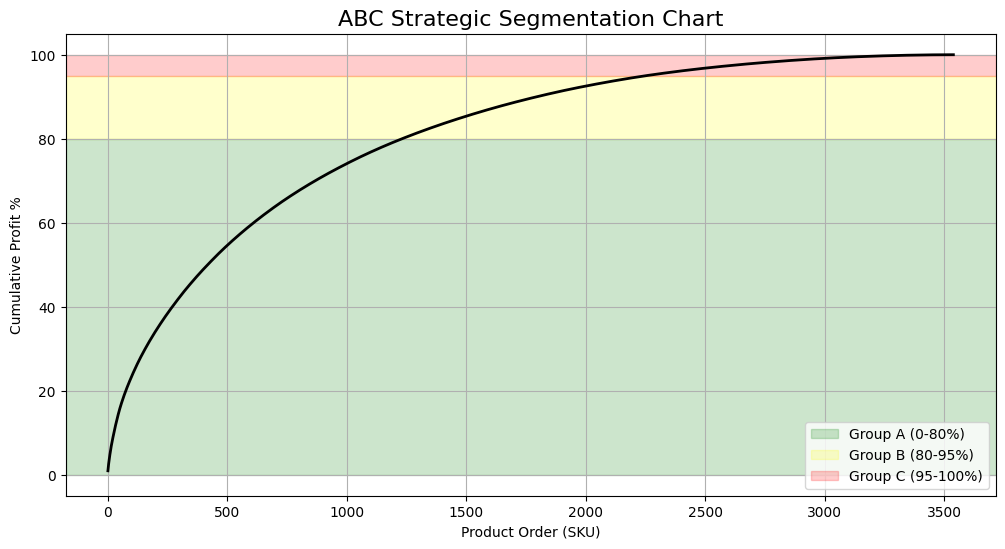

In [ ]:
# --- CHART 2: CUMULATIVE CURVE AND STRATEGIC SEGMENTATION ---
plt.figure(figsize=(12, 6))
plt.plot(product_profit.index, product_profit['Cumulative_Percentage'] * 100, color='black', linewidth=2)

# Shade the background for A, B, C regions
plt.axhspan(0, 80, color='green', alpha=0.2, label='Group A (0-80%)')
plt.axhspan(80, 95, color='yellow', alpha=0.2, label='Group B (80-95%)')
plt.axhspan(95, 100, color='red', alpha=0.2, label='Group C (95-100%)')

plt.title('ABC Strategic Segmentation Chart', fontsize=16)
plt.xlabel('Product Order (SKU)')
plt.ylabel('Cumulative Profit %')
plt.legend()
plt.grid(True)

plt.show()

**Key insight:** The ABC analysis on profitable products strongly confirms the Pareto Principle: approximately 35% of products (Group A) contribute to nearly 80% of the total profit. Group B products account for another 15% of profit with 29% of products, while 36% of products (Group C) contribute only 5% of the total profit.

## **5.2. Workstream 2: Strategic Customer Loyalty Program**

In [ ]:
# Merge data
customer_sales = pd.merge(sales, customers, on='CustomerID', how='left')
customer_sales.head(2)

# Filter profit > 0
customer_sales = customer_sales[customer_sales['Profit'] > 0]
customer_sales.head(2)


,RowID,OrderID,OrderDate,CustomerID,Segment,RegionCode,ProductCode,Quantity,Sales,Discount,...,FirstName,LastName,BirthDate,MaritalStatus,Gender,EmailAddress,AnnualIncome,EducationLevel,Occupation,HomeOwner
0,25221,IN-2012-TH211151-41003,2020-04-04,TH-211151,Corporate,RRR0001,P000001,13,416,0.0,...,Jon,Huang,6/18/1962,M,M,jon24@hotmail.com,90000,Bachelors,Professional,Y
1,29464,ID-2013-BD116051-41518,2021-09-01,BD-116051,Consumer,R0002,PPP000002,4,20,0.0,...,Eugene,Torres,6/16/1985,S,M,eugene10@hotmail.com,60000,Bachelors,Professional,N


In [ ]:
# Calculate profit by Customer ID
customer_profit = customer_sales.groupby('CustomerID', as_index= False).agg(Total_Profit = ('Profit', 'sum')).sort_values(by='Total_Profit', ascending=False)
sum_profit = customer_profit['Total_Profit'].sum()
customer_profit['Percentage'] = customer_profit['Total_Profit'] / sum_profit
customer_profit['Cumulative_Percentage'] = customer_profit['Percentage'].cumsum()
customer_profit.head(20)

,CustomerID,Total_Profit,Percentage,Cumulative_Percentage
892,AR-1082564,2625.300,0.001859,0.001859
8556,LS-172001402,2477.000,0.001754,0.003612
10002,MY-1829527,2165.000,0.001533,0.005145
9496,ML-73952,2156.000,0.001526,0.006672
14365,YS-2188093,2095.900,0.001484,0.008156
4651,EH-1376527,2089.100,0.001479,0.009635
10533,ON-1871545,2076.300,0.001470,0.011105
5395,GH-1448545,1985.200,0.001406,0.012510
12328,SC-2077058,1874.750,0.001327,0.013838
12809,SP-2054558,1849.150,0.001309,0.015147


In [ ]:
# determine cuting point
customer_profit.loc[customer_profit['Cumulative_Percentage'] <= 0.8, 'Group'] = 'A'
customer_profit.loc[(customer_profit['Cumulative_Percentage'] > 0.8) & (customer_profit['Cumulative_Percentage'] <= 0.9), 'Group'] = 'B'
customer_profit.loc[customer_profit['Cumulative_Percentage'] > 0.9, 'Group'] = 'C'
customer_profit.head(20)

,CustomerID,Total_Profit,Percentage,Cumulative_Percentage,Group
892,AR-1082564,2625.300,0.001859,0.001859,A
8556,LS-172001402,2477.000,0.001754,0.003612,A
10002,MY-1829527,2165.000,0.001533,0.005145,A
9496,ML-73952,2156.000,0.001526,0.006672,A
14365,YS-2188093,2095.900,0.001484,0.008156,A
4651,EH-1376527,2089.100,0.001479,0.009635,A
10533,ON-1871545,2076.300,0.001470,0.011105,A
5395,GH-1448545,1985.200,0.001406,0.012510,A
12328,SC-2077058,1874.750,0.001327,0.013838,A
12809,SP-2054558,1849.150,0.001309,0.015147,A


In [ ]:
# Merge customer_profit & customers
customer_profit = pd.merge(customer_profit, customers[['CustomerID','AnnualIncome', 'Occupation','EducationLevel']], on='CustomerID', how='left')
customer_profit.head(2)

,CustomerID,Total_Profit,Percentage,Cumulative_Percentage,Group,AnnualIncome_x,Occupation_x,AnnualIncome_y,Occupation_y,EducationLevel
0,AR-1082564,2625.3,0.001859,0.001859,A,40000,Skilled Manual,40000,Skilled Manual,Bachelors
1,LS-172001402,2477.0,0.001754,0.003612,A,70000,Skilled Manual,70000,Skilled Manual,Bachelors


In [ ]:
# abc summary
summary_abc = customer_profit.groupby('Group', as_index = False).agg(sum_profit = ('Total_Profit', 'sum'),
                                                                    Total_customer = ('CustomerID','count'))
summary_abc['Profit_pct'] = summary_abc['sum_profit'] / summary_abc['sum_profit'].sum()
summary_abc['Customer_pct'] = summary_abc['Total_customer'] / summary_abc['Total_customer'].sum()
summary_abc.head()

,Group,sum_profit,Total_customer,Profit_pct,Customer_pct
0,A,1129909.568,4314,0.799992,0.299625
1,B,141232.152,2160,0.099994,0.150021
2,C,141260.158,7924,0.100014,0.550354


**Profit contribution & Number of customer**

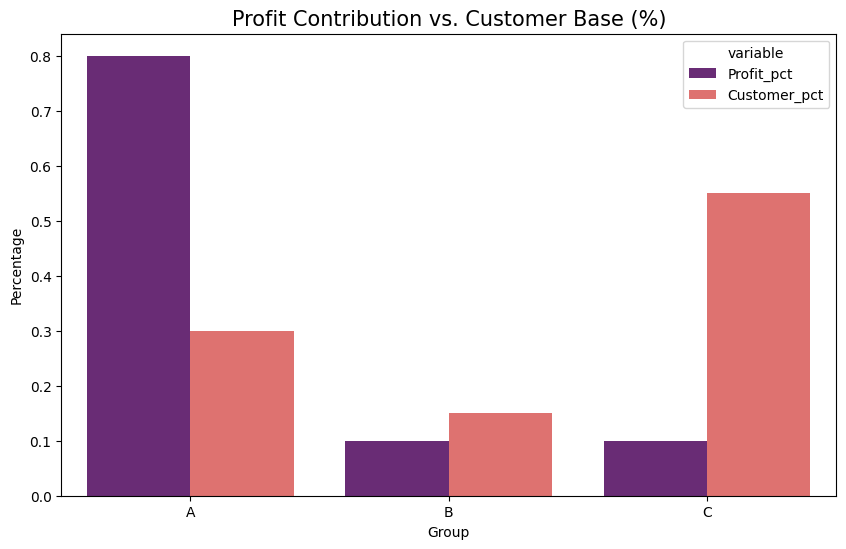

In [ ]:
summary_melted = summary_abc.melt(id_vars='Group', value_vars=['Profit_pct', 'Customer_pct'])

plt.figure(figsize=(10, 6))
sns.barplot(data=summary_melted, x='Group', y='value', hue='variable', palette='magma')
plt.title('Profit Contribution vs. Customer Base (%)', fontsize=15)
plt.ylabel('Percentage')
plt.show()

Group A (High-Value Customers): Approximately 30% of our customer base (4,314 customers) generates nearly 80% of the total profit. This is a strong validation of the Pareto Principle for customers, identifying them as our most valuable segment.
Group B (Medium-Value Customers): Around 15% of customers (2,160 customers) contribute about 10% of the total profit.
Group C (Low-Value Customers): The largest segment, comprising about 55% of customers (7,924 customers), contributes only approximately 10% of the total profit.

**Occupation Distribution**

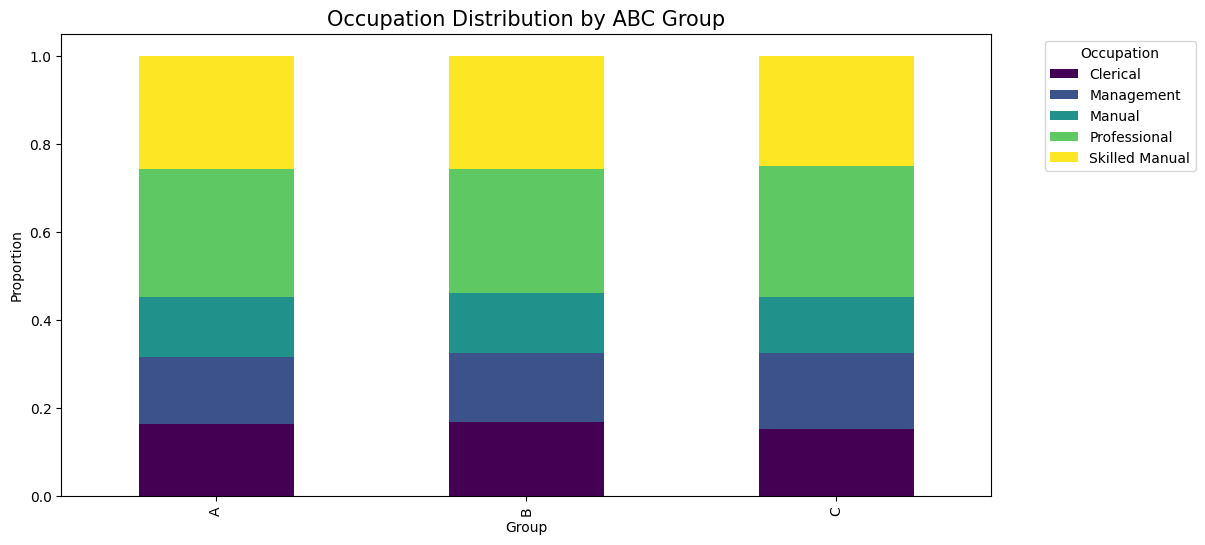

In [ ]:
occ_dist = pd.crosstab(customer_profit['Group'], customer_profit['Occupation_y'], normalize='index')

occ_dist.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='viridis')
plt.title('Occupation Distribution by ABC Group', fontsize=15)
plt.ylabel('Proportion')
plt.legend(title='Occupation', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

**Dominant Occupations:** Across all three groups (A, B, and C), 'Professional' and 'Skilled Manual' occupations consistently represent a significant portion of customers. 'Professional' is the largest segment in Group A and C, while 'Skilled Manual' is notably high in Group A.

- **Group A (High-Value)**: 'Professional' (approximately 29%) and 'Skilled Manual' (approximately 26%) are the most prominent occupations. This suggests that individuals in these roles contribute most to the high-profit customer base.

- **Group B (Medium-Value)**: The distribution is quite similar to Group A, with 'Professional' (approximately 28%) and 'Skilled Manual' (approximately 26%) leading, followed by 'Clerical' and 'Management'.

- **Group C (Low-Value)**: While 'Professional' still holds the largest share (approximately 30%), followed by 'Skilled Manual' (approximately 25%), the 'Management' category is slightly more represented here (approximately 17%) compared to Group A. This indicates that a diverse range of occupations exist across all profit segments, but 'Professional' and 'Skilled Manual' are key across the board.

**Income**

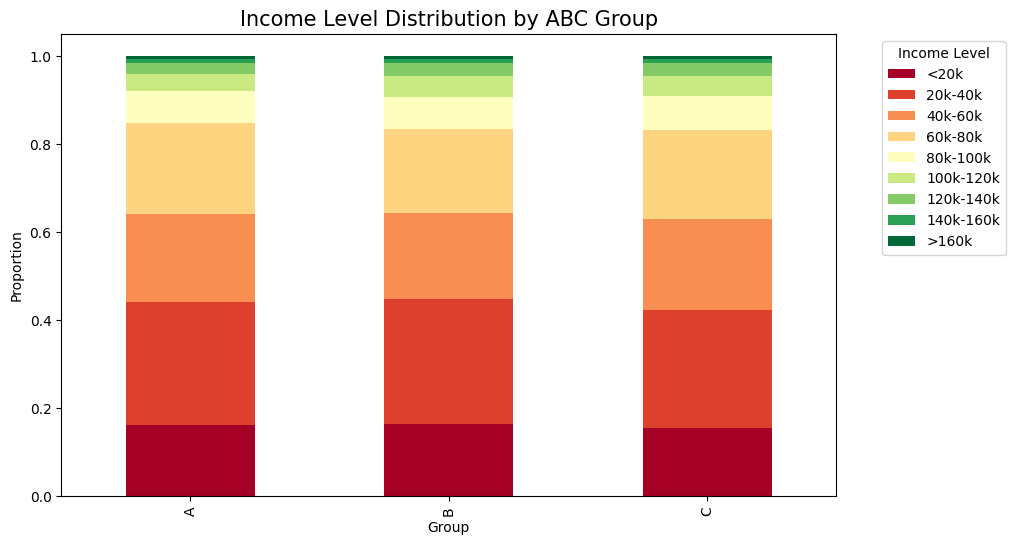

In [ ]:
income_bins = [0, 20000, 40000, 60000, 80000, 100000, 120000, 140000, 160000, 180000]
income_labels = ['<20k', '20k-40k', '40k-60k', '60k-80k', '80k-100k', '100k-120k', '120k-140k', '140k-160k', '>160k']

customer_profit['AnnualIncome_binned'] = pd.cut(customer_profit['AnnualIncome_y'], bins=income_bins, labels=income_labels, right=True)

income_dist = pd.crosstab(customer_profit['Group'], customer_profit['AnnualIncome_binned'], normalize='index')

income_dist.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='RdYlGn')
plt.title('Income Level Distribution by ABC Group', fontsize=15)
plt.ylabel('Proportion')
plt.legend(title='Income Level', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

- **Group A (High-Value):** While Group A customers are our most profitable, their income distribution largely mirrors that of Groups B and C. There isn't a stark concentration in the highest income brackets. For instance, the '20k-40k' group makes up the largest proportion (28%) in Group A, similar to Group B (28%) and Group C (~27%).

- **Higher Income Contribution (Slightly)**: Though not drastically different, Group A shows a slightly higher proportion of customers in the '100k-120k' income bracket compared to Group C. Similarly, Group B has a slightly higher percentage in the highest '>160k' bracket.

# **6. Insights & Strategic Recommendations**

## **6.1. Workstream 1: Inventory Strategy Optimization**

*   **Group A Products (High-Value - ~35% of Products, ~80% of Profit):**
    *   **Inventory Management:** Implement a rigorous inventory strategy with high stock levels to prevent stockouts. Prioritize these products for inventory accuracy and frequent audits.
    *   **Warehouse Allocation:** Allocate prime, easily accessible, and high-security warehouse space to these products to minimize picking time and potential losses.
    *   **Supply Chain:** Establish strong relationships with suppliers, consider multiple suppliers to mitigate risks, and prioritize expedited shipping options for these critical items.
    *   **Marketing:** Highlight these products in marketing campaigns and promotions, as they are proven profit drivers.

*   **Group B Products (Medium-Value - ~29% of Products, ~15% of Profit):**
    *   **Inventory Management:** Maintain optimal stock levels based on demand forecasts, using safety stock to buffer against moderate fluctuations. Implement standard inventory control practices.
    *   **Warehouse Allocation:** Store in accessible, but not necessarily prime, locations. Efficient racking and storage solutions are key.
    *   **Supply Chain:** Regular supplier communication and standard lead time management. Explore opportunities for cost-effective bulk purchasing without overstocking.
    *   **Marketing:** Include in general promotions or bundles, and monitor their performance for potential migration to Group A or C.

*   **Group C Products (Low-Value - ~36% of Products, ~5% of Profit):**
    *   **Inventory Management:** Minimize stock levels to reduce carrying costs and free up capital. Consider 'make-to-order' or dropshipping models where feasible. Evaluate for discontinuation if not strategically important or bundled with higher-value items.
    *   **Warehouse Allocation:** Store in less accessible or compact areas to save valuable space. Focus on efficient storage rather than rapid retrieval.
    *   **Supply Chain:** Negotiate for extended payment terms or explore consignment options. Prioritize cost reduction and efficient vendor management.
    *   **Marketing:** Avoid dedicated marketing spend. Consider bundling with Group A or B products, or offer clearance sales to clear stagnant inventory.

## **6.2. Workstream 2: Strategic Customer Loyalty Program**

*   **Group A Customers (High-Value - ~30% of Customers, ~80% of Profit):**
    *   **Persona:** Predominantly 'Professional' and 'Skilled Manual' occupations (29% and 26% respectively), with moderate to mid-high income levels (e.g., '20k-40k', '40k-60k'). High profitability is not exclusively tied to the highest income brackets but rather consistent purchasing behavior.
    *   **Loyalty Program:** These are your VIPs. Implement an exclusive loyalty program offering premium benefits, personalized experiences, early access to new products, and dedicated customer support. The objective of allocating 80% of the gift budget to Group A is validated as they drive the majority of the profit. This group should receive the 500 premium gift slots.
    *   **Engagement Strategy:** Maintain frequent, personalized communication (e.g., exclusive newsletters, early bird offers). Solicit feedback directly to foster a sense of belonging and influence product development.
    *   **Acquisition Strategy:** Leverage insights from their dominant occupations and income profiles to target similar demographics in future campaigns. Focus on channels and messaging that appeal to their professional and skilled manual backgrounds, emphasizing quality and value that resonate with their purchasing power.

*   **Group B Customers (Medium-Value - ~15% of Customers, ~10% of Profit):**
    *   **Persona:** Similar occupational and income distribution to Group A, suggesting they have the potential to migrate to Group A.
    *   **Loyalty Program:** Offer incentives to increase purchase frequency and average order value. Consider tiered loyalty programs where they can aspire to Group A benefits.
    *   **Engagement Strategy:** Engage with targeted promotions, cross-selling, and up-selling based on their purchase history. Encourage participation in surveys or product reviews.
    *   **Acquisition Strategy:** Identify specific attributes or behaviors that differentiate the high-profit Group A customers from this group, and tailor strategies to nudge Group B customers towards Group A buying patterns.

*   **Group C Customers (Low-Value - ~55% of Customers, ~10% of Profit):**
    *   **Persona:** Broad occupational and income distribution, with a slightly higher representation in 'Management' compared to Group A, but still dominated by 'Professional' and 'Skilled Manual'.
    *   **Loyalty Program:** Focus on cost-effective retention strategies. Offer basic loyalty rewards or seasonal discounts to encourage occasional purchases.
    *   **Engagement Strategy:** Utilize broad-reach marketing (e.g., social media, email campaigns) for new arrivals or popular items. Avoid high-cost personalized engagement unless specific segments show potential for growth.
    *   **Acquisition Strategy:** Analyze if these customers are new, infrequent, or one-time purchasers. If new, monitor for early signs of higher value. If infrequent, use promotions to reactivate. Consider if some 'long-tail' segments within Group C could be profitable with very low acquisition costs.